# Control Question Overlap Analysis

Examines how often the 5 control question variants (`question`, `deictic_removed`, `object_removed`,
`weaker_object`, `pronominalized`) produce **identical text** for the same question.

Overlaps reduce the effective number of degradation steps and affect the reliability of
tier D/E degradation metrics.

**Sections**
1. Pairwise overlap rates + heatmap
2. Per-question distinct-text count distribution
3. Most common collapse patterns
4. Zero-degradation questions (all 5 CTs identical)
5. Effective degradation steps vs acc_drop
6. Breakdown by entity group and operation type
7. Examples of each collapse pattern

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from collections import defaultdict
import sys, os
sys.path.insert(0, '/home/david/Desktop/yuna/HPA/analysis')
from utils.vqa import VQAAnswerMapper, vqa_accuracy

CONTROL_PATH   = '/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_control.jsonl'
SEMANTICS_PATH = '/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_semantics.jsonl'
SAMPLE_CSV     = '/home/david/Desktop/yuna/HPA/analysis/csv/sampled_control_questions.csv'
FIGURES_DIR    = '/home/david/Desktop/yuna/HPA/analysis/figures'

CT       = ['question', 'deictic_removed', 'object_removed', 'weaker_object', 'pronominalized']
CT_SHORT = {'question': 'Q', 'deictic_removed': 'D', 'object_removed': 'O',
            'weaker_object': 'W', 'pronominalized': 'P'}
CT_LABEL = {'question': 'Orig. Q', 'deictic_removed': 'Deictic Rm.',
            'object_removed': 'Object Rm.', 'weaker_object': 'Weaker Obj.',
            'pronominalized': 'Pronominalized'}

mapper  = VQAAnswerMapper()
sem_df  = pd.read_json(SEMANTICS_PATH, lines=True)
qdf_raw = pd.read_csv(SAMPLE_CSV)

# Load all control questions
records = []
with open(CONTROL_PATH) as f:
    for line in f:
        ex = json.loads(line)
        row = {'question_id': ex['question_id'], 'image_id': ex.get('image_id')}
        for ct in CT:
            row[ct] = ex.get(ct, '').strip()
        records.append(row)

ctrl_df = pd.DataFrame(records)
ctrl_df = ctrl_df.merge(sem_df[['question_id', 'ent', 'op', 'w']], on='question_id', how='left')
ctrl_df = ctrl_df.merge(
    qdf_raw[['question_id', 'acc_baseline', 'acc_drop', 'conf_drop',
              'overconfident_wrong', 'mean_output_changes', 'consensus_wrong']],
    on='question_id', how='left'
)

print(f'Loaded {len(ctrl_df)} questions')
print(f'Columns: {ctrl_df.columns.tolist()}')

Loaded 1000 questions
Columns: ['question_id', 'image_id', 'question', 'deictic_removed', 'object_removed', 'weaker_object', 'pronominalized', 'ent', 'op', 'w', 'acc_baseline', 'acc_drop', 'conf_drop', 'overconfident_wrong', 'mean_output_changes', 'consensus_wrong']


## 1. Pairwise Overlap Rates

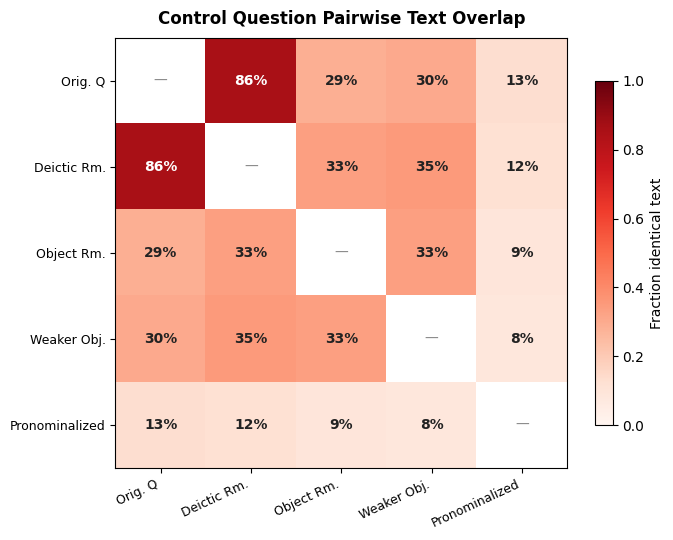

Pairwise overlap counts:
  Q == D:  857 / 1000 (85.7%)
  Q == O:  289 / 1000 (28.9%)
  Q == W:  304 / 1000 (30.4%)
  Q == P:  130 / 1000 (13.0%)
  D == O:  334 / 1000 (33.4%)
  D == W:  351 / 1000 (35.1%)
  D == P:  118 / 1000 (11.8%)
  O == W:  333 / 1000 (33.3%)
  O == P:   90 / 1000 (9.0%)
  W == P:   83 / 1000 (8.3%)


In [2]:
# Compute pairwise overlap matrix
n = len(CT)
overlap_mat = np.zeros((n, n))
for i, a in enumerate(CT):
    for j, b in enumerate(CT):
        if i == j:
            overlap_mat[i, j] = 1.0
        else:
            same = (ctrl_df[a].str.lower() == ctrl_df[b].str.lower()).sum()
            overlap_mat[i, j] = same / len(ctrl_df)

labels = [CT_LABEL[ct] for ct in CT]
overlap_pct = (overlap_mat * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 5.5))
mask = np.eye(n, dtype=bool)
cmap = sns.color_palette('Reds', as_cmap=True)
im = ax.imshow(np.where(mask, np.nan, overlap_mat), cmap=cmap, vmin=0, vmax=1, aspect='auto')

for i in range(n):
    for j in range(n):
        if i == j:
            ax.text(j, i, '—', ha='center', va='center', fontsize=10, color='#888')
        else:
            val = overlap_pct[i, j]
            color = 'white' if val > 55 else '#222'
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center', fontsize=10, color=color, fontweight='bold')

ax.set_xticks(range(n)); ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=9)
ax.set_yticks(range(n)); ax.set_yticklabels(labels, fontsize=9)
plt.colorbar(im, ax=ax, label='Fraction identical text', shrink=0.8)
ax.set_title('Control Question Pairwise Text Overlap', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/ctrl_overlap_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Pairwise overlap counts:')
for i, a in enumerate(CT):
    for j, b in enumerate(CT):
        if j > i:
            n_same = int(overlap_mat[i,j] * len(ctrl_df))
            print(f'  {CT_SHORT[a]} == {CT_SHORT[b]}: {n_same:4d} / {len(ctrl_df)} ({overlap_mat[i,j]*100:.1f}%)')

## 2. Per-Question Distinct Text Count

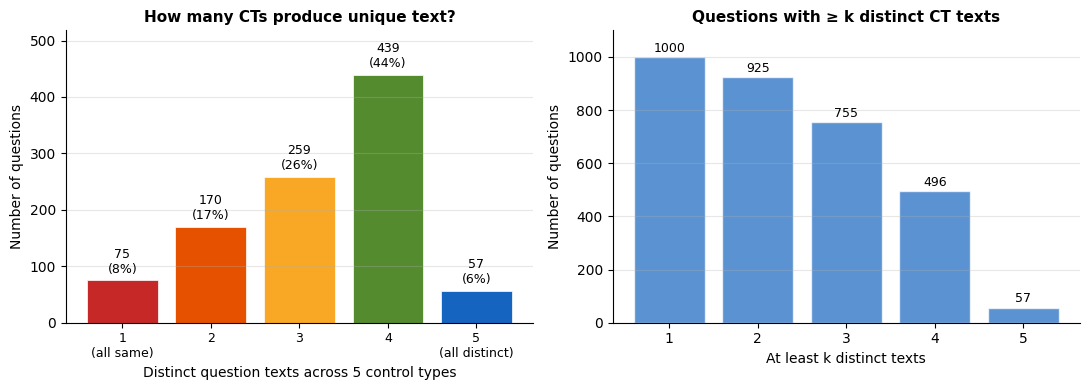

            count
n_distinct       
1              75
2             170
3             259
4             439
5              57


In [3]:
def n_distinct(row):
    texts = {row[ct].lower() for ct in CT if row[ct]}
    return len(texts)

ctrl_df['n_distinct'] = ctrl_df.apply(n_distinct, axis=1)

counts = ctrl_df['n_distinct'].value_counts().sort_index()
cumulative = counts[::-1].cumsum()[::-1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
colors = ['#c62828', '#e65100', '#f9a825', '#558b2f', '#1565c0']
bars = axes[0].bar(counts.index, counts.values, color=colors[:len(counts)], edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                 f'{val}\n({val/10:.0f}%)', ha='center', va='bottom', fontsize=9)
axes[0].set_xlabel('Distinct question texts across 5 control types', fontsize=10)
axes[0].set_ylabel('Number of questions', fontsize=10)
axes[0].set_title('How many CTs produce unique text?', fontsize=11, fontweight='bold')
axes[0].set_xticks(counts.index)
axes[0].set_xticklabels([f'{i}\n{"(all same)" if i==1 else "(all distinct)" if i==5 else ""}'
                          for i in counts.index], fontsize=9)
axes[0].set_ylim(0, max(counts.values) * 1.18)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# Cumulative: questions with ≥ k distinct texts
axes[1].bar(cumulative.index, cumulative.values, color='#1565c0', alpha=0.7, edgecolor='white')
for x, val in zip(cumulative.index, cumulative.values):
    axes[1].text(x, val + 8, f'{val}', ha='center', va='bottom', fontsize=9)
axes[1].set_xlabel('At least k distinct texts', fontsize=10)
axes[1].set_ylabel('Number of questions', fontsize=10)
axes[1].set_title('Questions with ≥ k distinct CT texts', fontsize=11, fontweight='bold')
axes[1].set_xticks(counts.index)
axes[1].set_ylim(0, 1100)
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/ctrl_distinct_count.png', dpi=150, bbox_inches='tight')
plt.show()

print(ctrl_df['n_distinct'].value_counts().sort_index().rename('count').to_frame())

## 3. Most Common Collapse Patterns

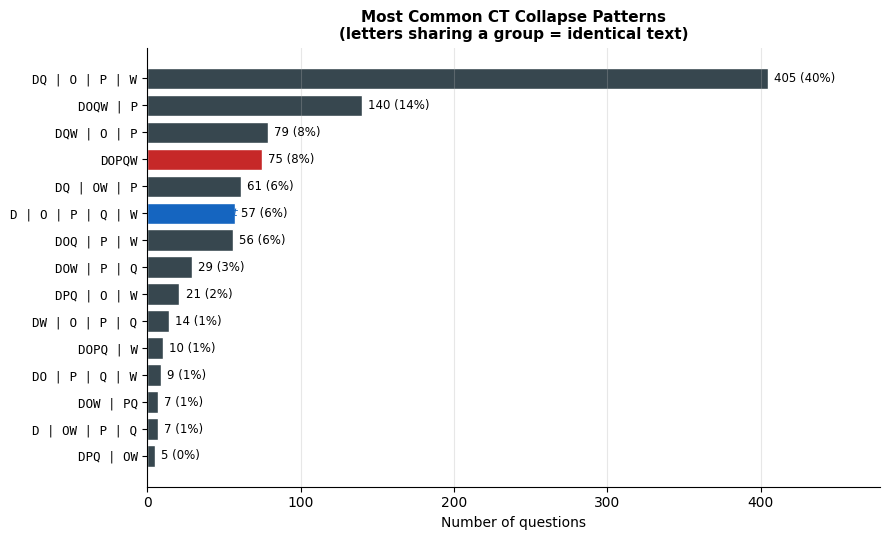

In [4]:
def collapse_pattern(row):
    text_to_cts = defaultdict(list)
    for ct in CT:
        t = row[ct].lower()
        if t:
            text_to_cts[t].append(CT_SHORT[ct])
    groups = sorted([''.join(sorted(v)) for v in text_to_cts.values()])
    return ' | '.join(groups)

ctrl_df['pattern'] = ctrl_df.apply(collapse_pattern, axis=1)

pat_counts = ctrl_df['pattern'].value_counts()
top_n = 15

fig, ax = plt.subplots(figsize=(9, 5.5))
top = pat_counts.head(top_n)
colors_bar = ['#c62828' if 'DOPQW' in p
              else '#1565c0' if p == 'D | O | P | Q | W'
              else '#37474f' for p in top.index]
bars = ax.barh(range(len(top)), top.values, color=colors_bar, edgecolor='white')
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top.index, fontsize=9, fontfamily='monospace')
ax.invert_yaxis()
for bar, val in zip(bars, top.values):
    ax.text(bar.get_width() + 4, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/10:.0f}%)', va='center', fontsize=8.5)
ax.set_xlabel('Number of questions', fontsize=10)
ax.set_title('Most Common CT Collapse Patterns\n(letters sharing a group = identical text)',
             fontsize=11, fontweight='bold')
ax.set_xlim(0, top.values.max() * 1.18)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

# Annotate special patterns
for i, (pat, val) in enumerate(top.items()):
    if pat == 'DOPQW':
        ax.text(4, i, ' ← all 5 identical', va='center', fontsize=8, color='#c62828', style='italic')
    elif pat == 'D | O | P | Q | W':
        ax.text(4, i, ' ← all 5 distinct', va='center', fontsize=8, color='#1565c0', style='italic')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/ctrl_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Zero-Degradation Questions (all 5 CTs identical)

In [5]:
flat = ctrl_df[ctrl_df['n_distinct'] == 1].copy()
print(f'Questions with all 5 CTs identical: {len(flat)}')
print(f'  Entity breakdown:\n{flat["ent"].value_counts().to_string()}')
print(f'\n  Op breakdown:\n{flat["op"].value_counts().head(10).to_string()}')

print('\nExamples:')
for _, row in flat.sample(6, random_state=42).iterrows():
    print(f'  [{row["ent"]:8s} | {str(row.get("op",""))[:10]:10s}] {row["question"]}')

Questions with all 5 CTs identical: 75
  Entity breakdown:
ent
other      31
person     22
object     10
place       7
text        3
food        1
product     1

  Op breakdown:
op
attr     30
exist    11
ident    10
spat      8
act       6
text      4
know      3
temp      1
other     1
cause     1

Examples:
  [person   | ident     ] What are they carrying?
  [object   | ident     ] What is the reflection?
  [other    | exist     ] Is it cloudy?
  [other    | ident     ] What sport is being played?
  [place    | ident     ] What room is this?
  [other    | attr      ] What time is it?


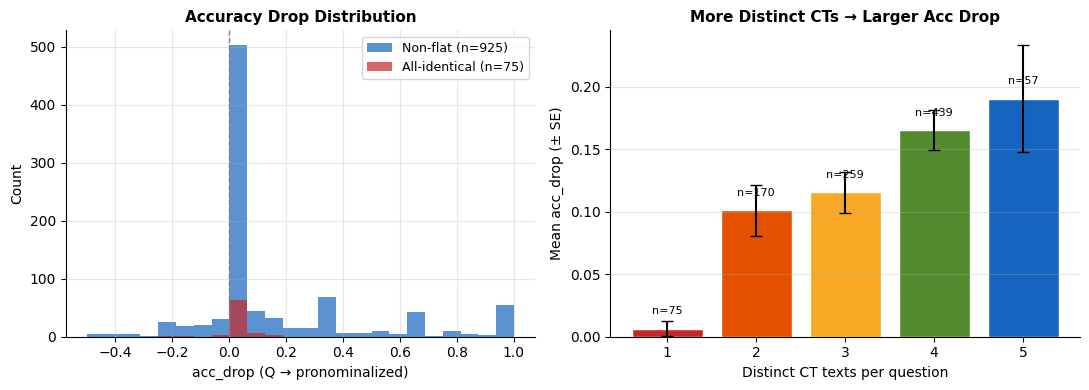

In [6]:
# Compare acc_drop distribution: flat vs non-flat questions
non_flat = ctrl_df[ctrl_df['n_distinct'] > 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# acc_drop distribution
bins = np.linspace(-0.5, 1.0, 25)
axes[0].hist(non_flat['acc_drop'].dropna(), bins=bins, alpha=0.7,
             label=f'Non-flat (n={len(non_flat)})', color='#1565c0')
axes[0].hist(flat['acc_drop'].dropna(), bins=bins, alpha=0.7,
             label=f'All-identical (n={len(flat)})', color='#c62828')
axes[0].axvline(0, color='gray', lw=1, ls='--')
axes[0].set_xlabel('acc_drop (Q → pronominalized)', fontsize=10)
axes[0].set_ylabel('Count', fontsize=10)
axes[0].set_title('Accuracy Drop Distribution', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3); axes[0].spines[['top','right']].set_visible(False)

# n_distinct vs mean acc_drop
grp = ctrl_df.groupby('n_distinct')['acc_drop'].agg(['mean', 'std', 'count']).reset_index()
axes[1].bar(grp['n_distinct'], grp['mean'],
            yerr=grp['std'] / np.sqrt(grp['count']),
            color=colors[:len(grp)], edgecolor='white', capsize=4)
for _, r in grp.iterrows():
    axes[1].text(r['n_distinct'], r['mean'] + 0.01, f'n={int(r["count"])}',
                 ha='center', va='bottom', fontsize=8)
axes[1].set_xlabel('Distinct CT texts per question', fontsize=10)
axes[1].set_ylabel('Mean acc_drop (± SE)', fontsize=10)
axes[1].set_title('More Distinct CTs → Larger Acc Drop', fontsize=11, fontweight='bold')
axes[1].set_xticks(grp['n_distinct'])
axes[1].grid(axis='y', alpha=0.3); axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/ctrl_flat_vs_varied.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. The Deictic Problem

857/1000 questions have `deictic_removed == question`. What makes the remaining 143 special?

In [7]:
ctrl_df['deictic_changed'] = (ctrl_df['question'].str.lower() != ctrl_df['deictic_removed'].str.lower())

print(f'Questions where deictic_removed differs from question: {ctrl_df["deictic_changed"].sum()}')
print(f'Questions where deictic_removed == question:           {(~ctrl_df["deictic_changed"]).sum()}')

# What deictic words were removed?
import re
deictic_words = ['this', 'that', 'these', 'those', 'here', 'there', 'the']
changed = ctrl_df[ctrl_df['deictic_changed']].copy()

# Find removed words by comparing question vs deictic_removed
removed_words = defaultdict(int)
for _, row in changed.iterrows():
    q_words  = set(re.findall(r'\b\w+\b', row['question'].lower()))
    d_words  = set(re.findall(r'\b\w+\b', row['deictic_removed'].lower()))
    for w in q_words - d_words:
        removed_words[w] += 1

print('\nMost commonly removed words:')
for w, cnt in sorted(removed_words.items(), key=lambda x: -x[1])[:15]:
    print(f'  {cnt:4d}  "{w}"')

print('\nExamples of deictic removal:')
for _, row in changed.sample(6, random_state=0).iterrows():
    print(f'  Q: {row["question"]}')
    print(f'  D: {row["deictic_removed"]}')
    print()

Questions where deictic_removed differs from question: 143
Questions where deictic_removed == question:           857

Most commonly removed words:
    87  "this"
    16  "these"
    10  "left"
     9  "the"
     8  "on"
     4  "right"
     3  "in"
     2  "of"
     2  "animals"
     2  "s"
     2  "there"
     2  "that"
     1  "background"
     1  "mans"
     1  "side"

Examples of deictic removal:
  Q: What does this animal eat?
  D: What does the animal eat?

  Q: Is this woman wearing a flower print dress?
  D: Is woman wearing a flower print dress?

  Q: Is this picture in focus?
  D: Is the picture in focus?

  Q: Do the horses love each other?
  D: Do horses love each other?

  Q: What is this bathroom missing?
  D: What is the bathroom missing?

  Q: Is the outside or inside?
  D: Is it outside or inside?



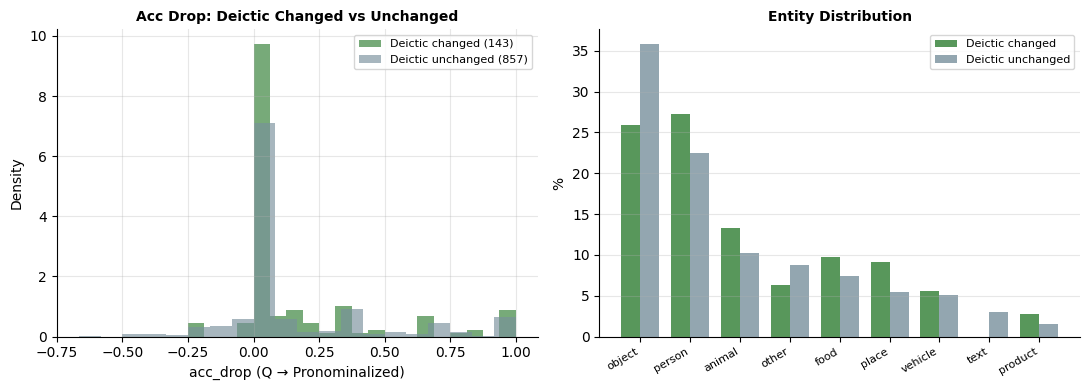

In [8]:
# Does deictic change correlate with acc_drop?
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for changed_val, label, color in [(True, 'Deictic changed (143)', '#2e7d32'),
                                    (False, 'Deictic unchanged (857)', '#78909c')]:
    sub = ctrl_df[ctrl_df['deictic_changed'] == changed_val]
    axes[0].hist(sub['acc_drop'].dropna(), bins=20, alpha=0.65,
                 label=label, color=color, density=True)

axes[0].set_xlabel('acc_drop (Q → Pronominalized)', fontsize=10)
axes[0].set_ylabel('Density', fontsize=10)
axes[0].set_title('Acc Drop: Deictic Changed vs Unchanged', fontsize=10, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3); axes[0].spines[['top','right']].set_visible(False)

# Entity breakdown of deictic-changed vs unchanged
ent_order = ctrl_df['ent'].value_counts().index.tolist()
changed_ent = ctrl_df[ctrl_df['deictic_changed']]['ent'].value_counts(normalize=True).reindex(ent_order, fill_value=0)
unchanged_ent = ctrl_df[~ctrl_df['deictic_changed']]['ent'].value_counts(normalize=True).reindex(ent_order, fill_value=0)

x = np.arange(len(ent_order))
w = 0.38
axes[1].bar(x - w/2, changed_ent.values * 100,   w, label='Deictic changed',   color='#2e7d32', alpha=0.8)
axes[1].bar(x + w/2, unchanged_ent.values * 100, w, label='Deictic unchanged', color='#78909c', alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(ent_order, rotation=30, ha='right', fontsize=8)
axes[1].set_ylabel('%', fontsize=10)
axes[1].set_title('Entity Distribution', fontsize=10, fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.3); axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/ctrl_deictic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Effective Degradation Steps by Entity & Op

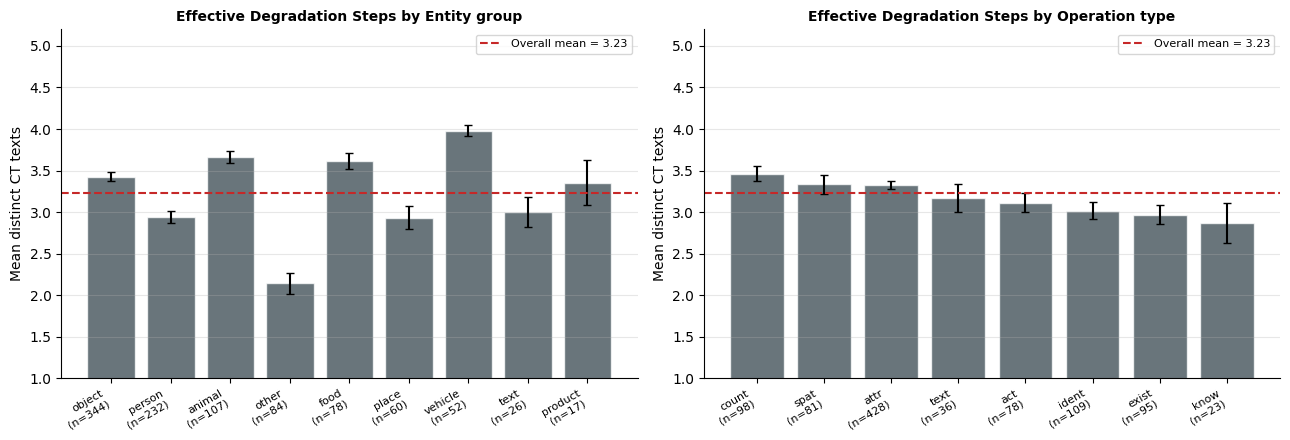

In [9]:
# Mean n_distinct per entity group
ent_order = ctrl_df['ent'].value_counts().index.tolist()
ent_grp = ctrl_df.groupby('ent')['n_distinct'].agg(['mean','std','count']).reindex(ent_order)

# Top op types
top_ops = ctrl_df['op'].value_counts().head(8).index.tolist()
op_grp  = ctrl_df[ctrl_df['op'].isin(top_ops)].groupby('op')['n_distinct'].agg(['mean','std','count'])
op_grp  = op_grp.sort_values('mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, grp, xlabel in [(axes[0], ent_grp, 'Entity group'),
                         (axes[1], op_grp,  'Operation type')]:
    bars = ax.bar(range(len(grp)), grp['mean'],
                  yerr=grp['std'] / np.sqrt(grp['count']),
                  color='#37474f', alpha=0.75, edgecolor='white', capsize=3)
    ax.axhline(ctrl_df['n_distinct'].mean(), color='#c62828', lw=1.5, ls='--',
               label=f'Overall mean = {ctrl_df["n_distinct"].mean():.2f}')
    ax.set_xticks(range(len(grp)))
    ax.set_xticklabels([f'{idx}\n(n={int(r["count"])})' for idx, r in grp.iterrows()],
                        rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Mean distinct CT texts', fontsize=10)
    ax.set_title(f'Effective Degradation Steps by {xlabel}', fontsize=10, fontweight='bold')
    ax.set_ylim(1, 5.2)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3); ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/ctrl_distinct_by_group.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Examples of Each Collapse Pattern

In [10]:
# Show one example for each of the top-8 most common patterns
top_patterns = pat_counts.head(8).index.tolist()

for pat in top_patterns:
    sub = ctrl_df[ctrl_df['pattern'] == pat]
    row = sub.sample(1, random_state=42).iloc[0]
    print(f'Pattern: {pat}  (n={len(sub)})  [{row["ent"]} | op={row.get("op","?")}]')
    for ct in CT:
        marker = '→' if row[ct].lower() != row['question'].lower() else ' '
        print(f'  {marker} {CT_SHORT[ct]}: {row[ct]}')
    print()

Pattern: DQ | O | P | W  (n=405)  [object | op=attr]
    Q: What color are the clock's numerals?
    D: What color are the clock's numerals?
  → O: What color are the object's numerals?
  → W: What color are the clock's digits?
  → P: What color are they?

Pattern: DOQW | P  (n=140)  [object | op=ident]
    Q: What base is pictured?
    D: What base is pictured?
    O: What base is pictured?
    W: What base is pictured?
  → P: What is pictured?

Pattern: DQW | O | P  (n=79)  [animal | op=ident]
    Q: What animal is shown?
    D: What animal is shown?
  → O: What object is shown?
    W: What animal is shown?
  → P: What is shown?

Pattern: DOPQW  (n=75)  [person | op=ident]
    Q: What are they carrying?
    D: What are they carrying?
    O: What are they carrying?
    W: What are they carrying?
    P: What are they carrying?

Pattern: DQ | OW | P  (n=61)  [person | op=comp]
    Q: Is more than one person flying a kite?
    D: Is more than one person flying a kite?
  → O: Is more than

## 8. Impact on Sampled Questions (Tier D / E)

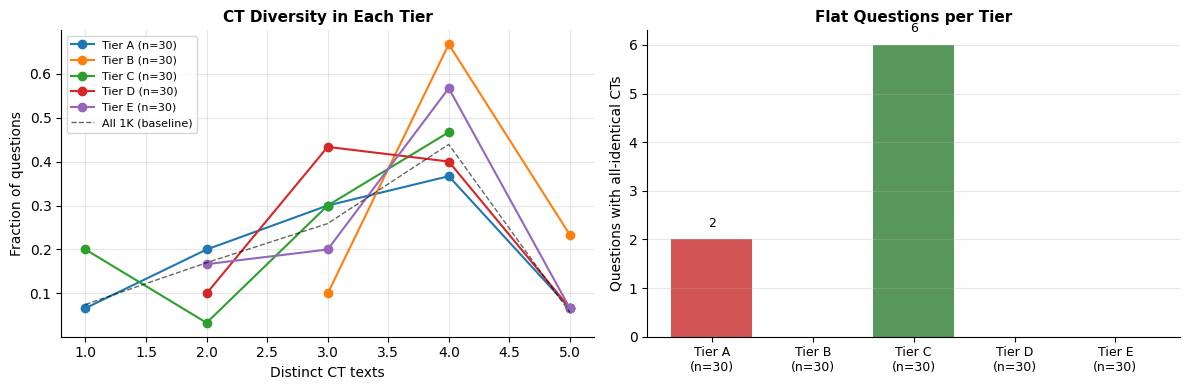

Mean n_distinct per tier:
  Tier A: mean=3.17, flat=2/30
  Tier B: mean=4.13, flat=0/30
  Tier C: mean=3.03, flat=6/30
  Tier D: mean=3.43, flat=0/30
  Tier E: mean=3.53, flat=0/30


In [11]:
import numpy as np
np.random.seed(42)

def strat_sample(mask, n=30, seed=42):
    pool = qdf_raw[mask].copy()
    if len(pool) == 0: return set()
    counts = pool['ent'].value_counts(normalize=True)
    out = []
    for ent, frac in counts.items():
        k = max(1, round(n * frac))
        sub = pool[pool['ent'] == ent]
        out.extend(sub.sample(min(k, len(sub)), random_state=seed)['question_id'].tolist())
    return set(list(set(out))[:n])

tier_sets = {
    'A': strat_sample(qdf_raw['overconfident_wrong']),
    'B': strat_sample(qdf_raw['mean_output_changes'] > 2),
    'C': strat_sample(qdf_raw['consensus_wrong']),
    'D': strat_sample(qdf_raw['acc_drop'] > 0.3),
    'E': strat_sample((qdf_raw['conf_drop'] > 0.05) & (qdf_raw['acc_baseline'] > 0.5)),
}
all_sampled = set.union(*tier_sets.values())

sampled_df = ctrl_df[ctrl_df['question_id'].isin(all_sampled)].copy()
sampled_df['tiers'] = sampled_df['question_id'].apply(
    lambda q: ''.join(t for t in 'ABCDE' if q in tier_sets[t]))

# n_distinct distribution in sampled vs full set
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for tier in 'ABCDE':
    tier_q = sampled_df[sampled_df['tiers'].str.contains(tier)]
    dist = tier_q['n_distinct'].value_counts().sort_index()
    axes[0].plot(dist.index, dist.values / len(tier_q), marker='o', label=f'Tier {tier} (n={len(tier_q)})', lw=1.5)

full_dist = ctrl_df['n_distinct'].value_counts(normalize=True).sort_index()
axes[0].plot(full_dist.index, full_dist.values, 'k--', lw=1, label='All 1K (baseline)', alpha=0.6)
axes[0].set_xlabel('Distinct CT texts', fontsize=10)
axes[0].set_ylabel('Fraction of questions', fontsize=10)
axes[0].set_title('CT Diversity in Each Tier', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# How many sampled questions have flat CTs?
flat_by_tier = {}
for tier in 'ABCDE':
    tier_q = sampled_df[sampled_df['tiers'].str.contains(tier)]
    flat_by_tier[tier] = (tier_q['n_distinct'] == 1).sum()

tier_sizes = {t: len(sampled_df[sampled_df['tiers'].str.contains(t)]) for t in 'ABCDE'}
x = np.arange(5)
axes[1].bar(x, [flat_by_tier[t] for t in 'ABCDE'],
            color=['#c62828','#1565c0','#2e7d32','#e65100','#6a1b9a'], alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'Tier {t}\n(n={tier_sizes[t]})' for t in 'ABCDE'], fontsize=9)
axes[1].set_ylabel('Questions with all-identical CTs', fontsize=10)
axes[1].set_title('Flat Questions per Tier', fontsize=11, fontweight='bold')
for xi, t in enumerate('ABCDE'):
    v = flat_by_tier[t]
    if v > 0:
        axes[1].text(xi, v + 0.2, str(v), ha='center', va='bottom', fontsize=9)
axes[1].grid(axis='y', alpha=0.3); axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/ctrl_overlap_by_tier.png', dpi=150, bbox_inches='tight')
plt.show()

print('Mean n_distinct per tier:')
for tier in 'ABCDE':
    tier_q = sampled_df[sampled_df['tiers'].str.contains(tier)]
    print(f'  Tier {tier}: mean={tier_q["n_distinct"].mean():.2f}, flat={flat_by_tier[tier]}/{len(tier_q)}')